In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller

 **Load the Processed Data**

In [40]:
data = pd.read_csv('processed_stock_data.csv', parse_dates=['Date'], index_col='Date')
data.head()


,Open,High,Low,Close,Volume,50-day MA,200-day MA,Close_diff,lag_1,lag_7,rolling_mean_7,rolling_std_7
Date,,,,,,,,,,,,
2012-10-16,90.767143,92.900002,90.142860,92.827141,137442900,94.422257,82.828500,2.147141,90.680000,93.227142,90.965102,1.040862
2012-10-17,92.695717,93.255714,92.000000,92.087143,97259400,94.489971,82.995200,-0.739998,92.827141,91.167145,91.096530,1.125285
2012-10-18,91.370003,91.722855,90.000000,90.377144,119156100,94.526486,83.151771,-1.709999,92.087143,90.835716,91.031020,1.155930
2012-10-19,90.150002,90.252853,87.088570,87.120003,145397275,94.495372,83.288779,-3.257141,90.377144,91.558571,90.396939,1.835773
2012-10-22,87.488571,90.768570,87.251427,90.575714,136682700,94.530600,83.439943,3.455711,87.120003,89.728569,90.517960,1.812140


In [41]:
series = data["Close"]
series

Date
2012-10-16     92.827141
2012-10-17     92.087143
2012-10-18     90.377144
2012-10-19     87.120003
2012-10-22     90.575714
                 ...    
2019-12-23    283.809289
2019-12-24    283.809289
2019-12-26    283.809289
2019-12-27    283.809289
2019-12-30    283.809289
Name: Close, Length: 1812, dtype: float64

**Arima model building**
- ARIMA is composed of 3 terms(Auto-Regression(p) + Integrated(d) + Moving-Average(q))
- First, we need to find out the order of arima model.

In [42]:
#find out order of arima
order = auto_arima(data['Close'])
order

ARIMA(order=(0, 1, 0), scoring_args={}, suppress_warnings=True)

In [43]:
# Split data into training and testing sets
train = series.iloc[:-30]
test = series.iloc[-30:]

**Fit the ARIMA model on the training set**

In [44]:
model = ARIMA(train, order=(0, 1, 0))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1782
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -3916.536
Date:                Tue, 25 Feb 2025   AIC                           7835.073
Time:                        19:07:17   BIC                           7840.557
Sample:                             0   HQIC                          7837.098
                               - 1782                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         4.7600      0.078     61.237      0.000       4.608       4.912
Ljung-Box (L1) (Q):                   0.17   Jarque-Bera (JB):              3236.74
Prob(Q):                              0.68   Pr

c:\Users\vimal\OneDrive\Desktop\Apple stock Forecast\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\vimal\OneDrive\Desktop\Apple stock Forecast\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\vimal\OneDrive\Desktop\Apple stock Forecast\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [45]:
# Forecast for the test period
forecast = model_fit.forecast(steps=30)
forecast

c:\Users\vimal\OneDrive\Desktop\Apple stock Forecast\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\vimal\OneDrive\Desktop\Apple stock Forecast\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


1782    262.640015
1783    262.640015
1784    262.640015
1785    262.640015
1786    262.640015
1787    262.640015
1788    262.640015
1789    262.640015
1790    262.640015
1791    262.640015
1792    262.640015
1793    262.640015
1794    262.640015
1795    262.640015
1796    262.640015
1797    262.640015
1798    262.640015
1799    262.640015
1800    262.640015
1801    262.640015
1802    262.640015
1803    262.640015
1804    262.640015
1805    262.640015
1806    262.640015
1807    262.640015
1808    262.640015
1809    262.640015
1810    262.640015
1811    262.640015
Name: predicted_mean, dtype: float64

In [46]:
# Calculate evaluation metrics
mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test - forecast) / test)) * 100
print("MAE: ", mae)
print("MSE: ", mse)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE:  9.225869449999994
MSE:  142.62979324165588
RMSE: 11.942771589612516
MAPE: nan


C:\Users\vimal\AppData\Local\Temp\ipykernel_18260\3067151740.py:5: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  mape = np.mean(np.abs((test - forecast) / test)) * 100


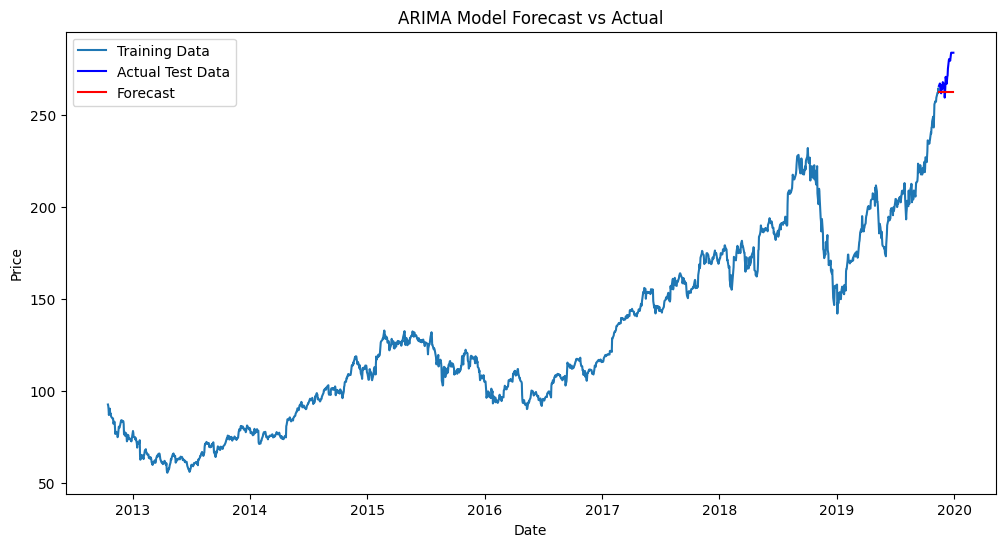

In [47]:
# Plot actual vs forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Test Data', color='blue')
plt.plot(test.index, forecast, label='Forecast', color='red')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('ARIMA Model Forecast vs Actual')
plt.legend()
plt.show()

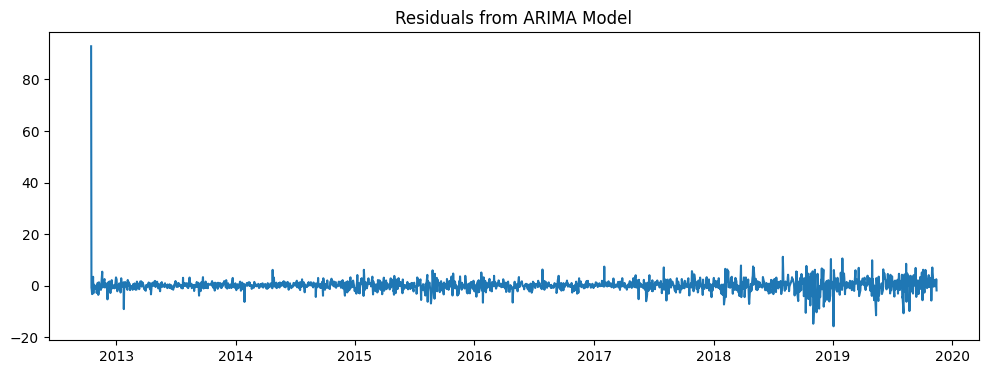

In [48]:
# Residual Analysis
residuals = model_fit.resid
plt.figure(figsize=(12, 4))
plt.plot(residuals)
plt.title('Residuals from ARIMA Model')
plt.show()

In [49]:
import numpy as np

def safe_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero: filter out indices where y_true is 0
    non_zero_indices = y_true != 0
    if not np.any(non_zero_indices):
        return np.nan
    return np.mean(np.abs((y_true[non_zero_indices] - y_pred[non_zero_indices]) / y_true[non_zero_indices])) * 100

mape = safe_mape(test, forecast)
print("Safe MAPE:", mape)

Safe MAPE: 3.3204603167021514


**Define and fit the SARIMA model**

In [50]:
result = adfuller(data["Close"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 1.10067426385538
p-value: 0.9952223730240793


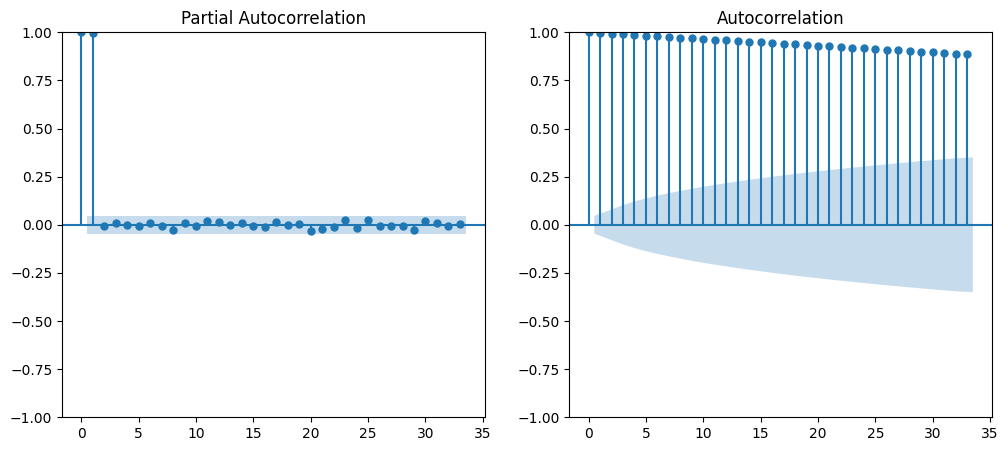

In [51]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_pacf(data["Close"], ax=ax[0])
plot_acf(data["Close"], ax=ax[1])
plt.show()

In [52]:
result = adfuller(data['Close_diff'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -13.031824571356344
p-value: 2.3364259615740772e-24


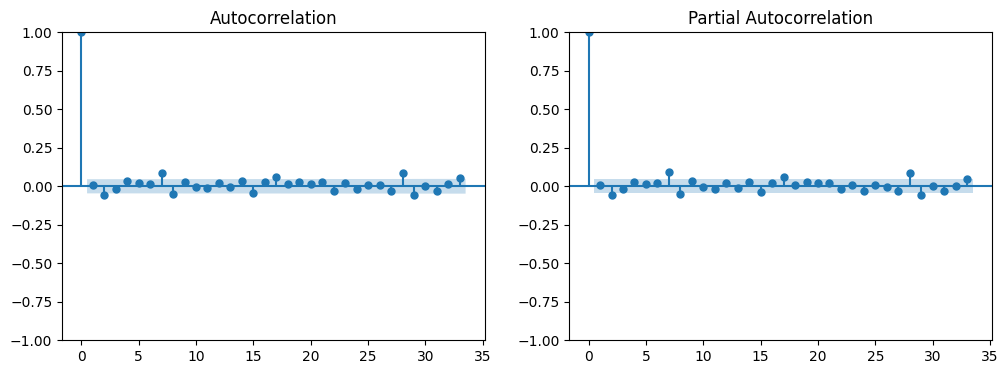

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(data['Close_diff'].dropna(), ax=axes[0])
plot_pacf(data['Close_diff'].dropna(), ax=axes[1])
plt.show()

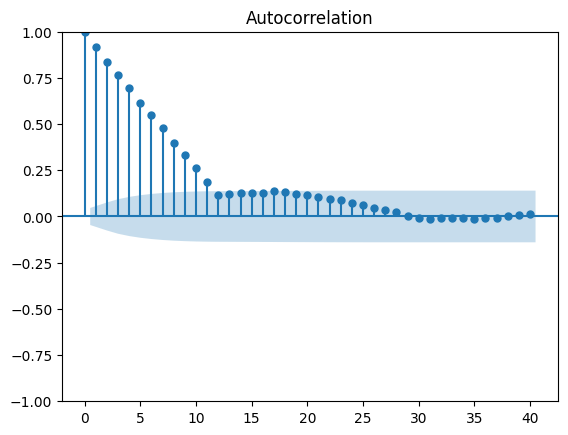

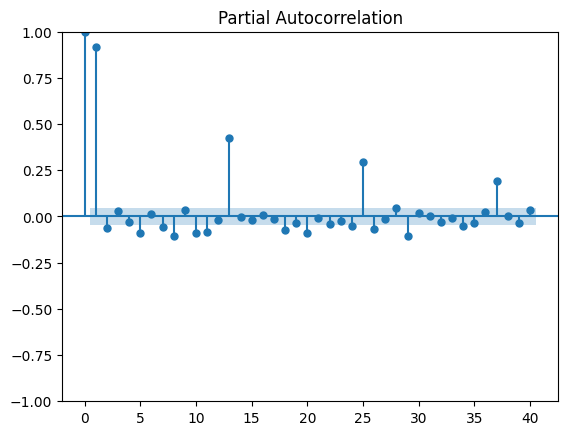

In [55]:
data['Close_seasonal_diff'] = data['Close'] - data['Close'].shift(12)
data.dropna(inplace=True)
plot_acf(data['Close_seasonal_diff'], lags=40)
plot_pacf(data['Close_seasonal_diff'], lags=40)
plt.show()

In [57]:
p, d, q = 1, 1, 1
P, D, Q, s = 1, 1, 1, 12

In [58]:
model = SARIMAX(data['Close'], order=(p, d, q), seasonal_order=(P, D, Q, s))
results = model.fit()
print(results.summary())

c:\Users\vimal\OneDrive\Desktop\Apple stock Forecast\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\vimal\OneDrive\Desktop\Apple stock Forecast\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              Close   No. Observations:                 1800
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -3965.405
Date:                            Tue, 25 Feb 2025   AIC                           7940.809
Time:                                    19:10:10   BIC                           7968.251
Sample:                                         0   HQIC                          7950.943
                                           - 1800                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8536      0.103     -8.313      0.000      -1.055      -0.652
ma.L1          0.8779      0.094   

In [59]:
# Forecast the next 30 steps (days)
forecast_object = results.get_forecast(steps=30)

c:\Users\vimal\OneDrive\Desktop\Apple stock Forecast\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\vimal\OneDrive\Desktop\Apple stock Forecast\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [60]:
predicted_values = forecast_object.predicted_mean

In [61]:
confidence_intervals = forecast_object.conf_int()

In [63]:
last_date = data.index[-1]
future_index = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30, freq='B')


In [64]:
forecast_df = pd.DataFrame({
    'Forecast': predicted_values
}, index=future_index)

In [65]:
print(forecast_df)

            Forecast
2019-12-31       NaN
2020-01-01       NaN
2020-01-02       NaN
2020-01-03       NaN
2020-01-06       NaN
2020-01-07       NaN
2020-01-08       NaN
2020-01-09       NaN
2020-01-10       NaN
2020-01-13       NaN
2020-01-14       NaN
2020-01-15       NaN
2020-01-16       NaN
2020-01-17       NaN
2020-01-20       NaN
2020-01-21       NaN
2020-01-22       NaN
2020-01-23       NaN
2020-01-24       NaN
2020-01-27       NaN
2020-01-28       NaN
2020-01-29       NaN
2020-01-30       NaN
2020-01-31       NaN
2020-02-03       NaN
2020-02-04       NaN
2020-02-05       NaN
2020-02-06       NaN
2020-02-07       NaN
2020-02-10       NaN


In [66]:
data.index = pd.to_datetime(data.index)

In [67]:
freq = pd.infer_freq(data.index)
print("Inferred frequency:", freq)

Inferred frequency: None


In [68]:
data = data.asfreq('B')

In [69]:
freq = pd.infer_freq(data.index)
print("Inferred frequency:", freq)

Inferred frequency: B


In [70]:
forecast_object = results.get_forecast(steps=30)
forecast_df = forecast_object.summary_frame()

c:\Users\vimal\OneDrive\Desktop\Apple stock Forecast\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\vimal\OneDrive\Desktop\Apple stock Forecast\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [71]:
print(forecast_df)

Close        mean    mean_se  mean_ci_lower  mean_ci_upper
1800   284.102551   2.200230     279.790180     288.414923
1801   284.538150   3.149582     278.365083     290.711218
1802   284.890977   3.846466     277.352041     292.429912
1803   285.020712   4.454674     276.289712     293.751711
1804   284.921675   4.974409     275.172012     294.671338
1805   284.902176   5.456347     274.207932     295.596421
1806   284.864553   5.889886     273.320589     296.408517
1807   285.145496   6.300941     272.795879     297.495114
1808   285.658613   6.680892     272.564306     298.752920
1809   285.520789   7.045130     271.712587     299.328991
1810   285.375934   7.387565     270.896573     299.855295
1811   286.075022   7.717982     270.948055     301.201990
1812   286.351798   8.053783     270.566674     302.136922
1813   286.731049   8.378834     270.308836     303.153262
1814   286.992133   8.689506     269.961014     304.023251
1815   287.119048   8.991289     269.496446     304.7416